In [1]:
import pandas as pd

In [2]:
df =pd.read_csv(r"C:\Users\Dell\Desktop\Shekhawat\ducat csv\Bengaluru_House_Data.csv")
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [3]:
# here 1st we will try to understadnd the data::::::

In [4]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [5]:
df.shape

(13320, 9)

In [6]:
df.dtypes  # python above 2 shows str below show object 

area_type        object
availability     object
location         object
size             object
society          object
total_sqft       object
bath            float64
balcony         float64
price           float64
dtype: object

In [7]:
df['location']= df['location'].fillna(df['location'].mode()[0])

In [8]:
df['size']= df['size'].fillna(df['size'].mode()[0])

In [9]:
df['bath']=df['bath'].fillna(df['bath'].mode()[0])
df['balcony']=df['balcony'].fillna(df['balcony'].mode()[0])

In [10]:
# Always first check all the columns describe so that you will be sure for categorical data either its fake or to keep

In [11]:
# Society:::::::::::::::
df['society'].describe()

count        7818
unique       2688
top       GrrvaGr
freq           80
Name: society, dtype: object

In [12]:
print(df['society'].str.len().describe())

count    7818.0
mean        7.0
std         0.0
min         7.0
25%         7.0
50%         7.0
75%         7.0
max         7.0
Name: society, dtype: float64


# what is standard deviation:::
“On average, how far each value is from the mean.”
-

In [13]:
df=df.drop(columns=['society'])

In [14]:
df[['size_num','size_unit']]=df['size'].str.split(" ",expand= True)

In [15]:
df['size_unit'].value_counts()


size_unit
BHK        10782
Bedroom     2525
RK            13
Name: count, dtype: int64

In [16]:
# If to keep size_unit i can drop RK....... Lets try!

In [17]:
df=df[df['size_unit'] != 'RK']
df.isnull().sum() # This only counts missing (null) values, not deleted rows
df['size_unit'].value_counts() # so here i have completely deleted the row of RK with all columns

size_unit
BHK        10782
Bedroom     2525
Name: count, dtype: int64

In [18]:
# however as per property dealing bhk and bedroom are considered same 

In [19]:
try:
    df=df.drop(columns=['size_unit'])
    df=df.drop(columns=['size'])
except KeyError:
    print('its done already')

In [20]:
df.dtypes

area_type        object
availability     object
location         object
total_sqft       object
bath            float64
balcony         float64
price           float64
size_num         object
dtype: object

In [21]:
df

,area_type,availability,location,total_sqft,bath,balcony,price,size_num
0,Super built-up Area,19-Dec,Electronic City Phase II,1056,2.0,1.0,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,2600,5.0,3.0,120.00,4
2,Built-up Area,Ready To Move,Uttarahalli,1440,2.0,3.0,62.00,3
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521,3.0,1.0,95.00,3
4,Super built-up Area,Ready To Move,Kothanur,1200,2.0,1.0,51.00,2
...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,3453,4.0,0.0,231.00,5
13316,Super built-up Area,Ready To Move,Richards Town,3600,5.0,2.0,400.00,4
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,1141,2.0,1.0,60.00,2
13318,Super built-up Area,18-Jun,Padmanabhanagar,4689,4.0,1.0,488.00,4


In [22]:
# here i have two method two proceed with same an objective find the error::
'''Case 1: total_sqft -- str = float or int 
---------------------------------------------------------------------------------------------------------
Case 2: size_num -- str = float or int'''

'Case 1: total_sqft -- str = float or int \n---------------------------------------------------------------------------------------------------------\nCase 2: size_num -- str = float or int'

In [23]:
df['total_sqft'].value_counts()
df['total_sqft'].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [24]:
inconsistent=[]
for value in df['total_sqft']:
    try:
        float(value)
    except:
        if value not in inconsistent:
            inconsistent.append(value)
print(inconsistent)
# not in + if + append → together acts like unique 
#-------------------------------------------------------------------------------------------------------------------------------
print()

print(pd.Series(list(inconsistent)).value_counts())

print()

print(len(inconsistent)) # counts unique # So if "34.46Sq. Meter" appears 10 times, it is counted only once in inconsistent.

pd.to_numeric(df['total_sqft'], errors = 'coerce').isnull().sum() # counts all

['2100 - 2850', '3010 - 3410', '2957 - 3450', '3067 - 8156', '1042 - 1105', '1145 - 1340', '1015 - 1540', '1520 - 1740', '34.46Sq. Meter', '1195 - 1440', '1200 - 2400', '4125Perch', '1120 - 1145', '4400 - 6640', '3090 - 5002', '4400 - 6800', '1160 - 1195', '1000Sq. Meter', '4000 - 5249', '1115 - 1130', '1100Sq. Yards', '520 - 645', '1000 - 1285', '3606 - 5091', '650 - 665', '633 - 666', '5.31Acres', '30Acres', '1445 - 1455', '884 - 1116', '850 - 1093', '1440 - 1884', '716Sq. Meter', '547.34 - 827.31', '580 - 650', '3425 - 3435', '1804 - 2273', '3630 - 3800', '660 - 670', '1500Sq. Meter', '620 - 933', '142.61Sq. Meter', '2695 - 2940', '2000 - 5634', '1574Sq. Yards', '3450 - 3472', '1250 - 1305', '670 - 980', '1005.03 - 1252.49', '1004 - 1204', '361.33Sq. Yards', '645 - 936', '2710 - 3360', '2249.81 - 4112.19', '3436 - 3643', '2830 - 2882', '596 - 804', '1255 - 1863', '1300 - 1405', '1500 - 2400', '117Sq. Yards', '934 - 1437', '980 - 1030', '1564 - 1850', '1446 - 1506', '1070 - 1315', '3

np.int64(246)

# Dry Run to understand pd.to_numeric()
        total_sqft               After to_numeric                       After isnull()
1.       "1056"                    1056.0                                  False
2.     "2100 - 2850"                NaN                                    True
3.     "34.46Sq. Meter"             NaN                                    True
4.       "1200"                   1200.0                                  False 

In [25]:
# sorting making it super easy to understand the data 
inconsistent_sorted = sorted(inconsistent)

for value in inconsistent_sorted:
    print(value)

1.25Acres
1.26Acres
1000 - 1285
1000Sq. Meter
1004 - 1204
1005.03 - 1252.49
1010 - 1300
1015 - 1540
1020 - 1130
1042 - 1105
1052 - 1322
1070 - 1315
1076 - 1199
1079 - 1183
1100 - 1225
1100Sq. Meter
1100Sq. Yards
1115 - 1130
1120 - 1145
1125 - 1500
1133 - 1384
1140 - 1250
1145 - 1340
1150 - 1194
1160 - 1195
1160 - 1315
117Sq. Yards
1180 - 1630
1195 - 1440
1200 - 1470
1200 - 1800
1200 - 2400
120Sq. Yards
1210 - 1477
1215 - 1495
122Sq. Yards
1230 - 1290
1230 - 1490
1235 - 1410
1250 - 1305
1255 - 1350
1255 - 1375
1255 - 1863
1270 - 1275
1300 - 1405
1310 - 1615
132Sq. Yards
133.3Sq. Yards
1349 - 3324
1360 - 1890
1365 - 1700
1390 - 1600
1400 - 1421
1408 - 1455
1410 - 1710
142.61Sq. Meter
142.84Sq. Meter
1430 - 1630
1437 - 1629
1440 - 1884
1445 - 1455
1446 - 1506
1450 - 1595
1450 - 1950
1469 - 1766
1482 - 1684
1482 - 1846
1500 - 2400
1500Cents
1500Sq. Meter
151.11Sq. Yards
1510 - 1670
1520 - 1740
1520 - 1759
1550 - 1590
1564 - 1850
1565 - 1595
1574Sq. Yards
15Acres
1610 - 1880
1618 - 1929
165

In [26]:
# additional learning:::::::::::::::::::::::::::::::::::::::::
from collections import Counter #(#project work)

freq = Counter(inconsistent)

print(freq)

Counter({'2100 - 2850': 1, '3010 - 3410': 1, '2957 - 3450': 1, '3067 - 8156': 1, '1042 - 1105': 1, '1145 - 1340': 1, '1015 - 1540': 1, '1520 - 1740': 1, '34.46Sq. Meter': 1, '1195 - 1440': 1, '1200 - 2400': 1, '4125Perch': 1, '1120 - 1145': 1, '4400 - 6640': 1, '3090 - 5002': 1, '4400 - 6800': 1, '1160 - 1195': 1, '1000Sq. Meter': 1, '4000 - 5249': 1, '1115 - 1130': 1, '1100Sq. Yards': 1, '520 - 645': 1, '1000 - 1285': 1, '3606 - 5091': 1, '650 - 665': 1, '633 - 666': 1, '5.31Acres': 1, '30Acres': 1, '1445 - 1455': 1, '884 - 1116': 1, '850 - 1093': 1, '1440 - 1884': 1, '716Sq. Meter': 1, '547.34 - 827.31': 1, '580 - 650': 1, '3425 - 3435': 1, '1804 - 2273': 1, '3630 - 3800': 1, '660 - 670': 1, '1500Sq. Meter': 1, '620 - 933': 1, '142.61Sq. Meter': 1, '2695 - 2940': 1, '2000 - 5634': 1, '1574Sq. Yards': 1, '3450 - 3472': 1, '1250 - 1305': 1, '670 - 980': 1, '1005.03 - 1252.49': 1, '1004 - 1204': 1, '361.33Sq. Yards': 1, '645 - 936': 1, '2710 - 3360': 1, '2249.81 - 4112.19': 1, '3436 - 3

In [27]:
# Now removing all the error from total_sqft

In [28]:
def convert_sqft(x):
    # conversion factors to sqft
    units = {
        'Sq. Meter': 10.764,
        'Sq. Yards': 9,
        'Acres': 43560,
        'Guntha': 1089,
        'Cents': 435.6,
        'Perch': 272.25,
        'Grounds': 2400
    }
    try:
         # normal number → direct return
        return float(x)
    except:
        # range like "2100 - 2850" → return average
        if '-' in str(x):
            try:
                parts = x.split('-')
                return (float(parts[0]) + float(parts[1])) / 2
            except:
                return None
                # unit values → convert to sqft
        for unit, factor in units.items():
            if unit in str(x):
                try:
                    num = float(x.replace(unit, '').strip())
                    return num * factor
                except:
                    return None
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)

#why shape is not changed while use of dropna
# Because our convert_sqft() successfully converted ALL values — nothing became NaN!
df = df.dropna(subset=['total_sqft'])

df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']
df['total_sqft'].isnull().sum()
df


,area_type,availability,location,total_sqft,bath,balcony,price,size_num,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,1056.0,2.0,1.0,39.07,2,3699.810606
1,Plot Area,Ready To Move,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4,4615.384615
2,Built-up Area,Ready To Move,Uttarahalli,1440.0,2.0,3.0,62.00,3,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,1200.0,2.0,1.0,51.00,2,4250.000000
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,3453.0,4.0,0.0,231.00,5,6689.834926
13316,Super built-up Area,Ready To Move,Richards Town,3600.0,5.0,2.0,400.00,4,11111.111111
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,1141.0,2.0,1.0,60.00,2,5258.545136
13318,Super built-up Area,18-Jun,Padmanabhanagar,4689.0,4.0,1.0,488.00,4,10407.336319


In [29]:
df.shape # rk was removed before 

(13307, 9)

In [30]:
df.dtypes

area_type          object
availability       object
location           object
total_sqft        float64
bath              float64
balcony           float64
price             float64
size_num           object
price_per_sqft    float64
dtype: object

In [31]:
df['size_num']=df['size_num'].astype(int)
df.dtypes




area_type          object
availability       object
location           object
total_sqft        float64
bath              float64
balcony           float64
price             float64
size_num            int64
price_per_sqft    float64
dtype: object

# important Concepts for consideration::::::::

#        Situation                                                   Use
1.       Normal Python conditions                                   and / or ✅
2.       Pandas DataFrame/Series                                    & / | ✅

# Simple rule:

and / or → normal Python conditions ✅
& / | → Pandas filtering on DataFrame/Series ✅
-

# drop column = df.drop(columns=['col'])
# drop row  = df.dropna(subset=['col'])
-

# Questions
# 1. but then why to convert in str when everything in total_sqft is in string give me point to point answer only
:- Because NaN is not a string — it is a float!
:- type(np.nan)  # → float
:- So str(value) converts NaN → "nan"

# 2. str.replace(old, new)
:-text = "2apple"
text = text.replace("apple", "")
print(text) -- 2

# 3. strip() removes extra spaces from both sides of a string.

In [32]:
text = "hello world"
result = text.replace("world", "python")
print(result)

print()

text = "2apple"
text = text.replace("apple", "")
print(text) #"2"

# If you want 2 WITH space, your original text must have a space:
text = "2 apple"   # space present
text = text.replace("apple", "")
print(text)        # → "2 "  (with space)

hello python

2
2 


In [33]:
                                         # Lets also see this
 
def extract_number(y):
    try:
        for unit in y:
            if not unit.isdigit():
                y = y.replace(unit, "")
        return float(y)
    except:
        return 'didnt work out'
extract_number('12number')

12.0

In [34]:
# So Till Here I Have Done Basic Cleaning::::::::::

                                  # why price was multiplied with 1 lakh ?
                                 
#------- Basic understanding However also given in data that price is in lakh o need of asssumption...

# Here The Concept:

# Normal dictionary lookup
my_dict = {"Whitefield": 535, "HSR Layout": 185}
my_dict["Whitefield"]   # → 535
#       ↑ [] used to get value by key

# Pandas Series lookup → SAME concept!
location_stats["Whitefield"]   # → 535
#              ↑ [] used to get value by label

[] is always used to fetch a value — whether from a list, dictionary, or Pandas Series! ✅

In [35]:
df['location']=df['location'].apply(lambda x: x.strip())
location_stats = df['location'].value_counts() #here it is acting as a groupby
print(location_stats)
#Rare Location -- "Other"
df['location']= df['location'].apply(lambda x:x if location_stats[x]>10 else 'other')
df

location
Whitefield                              541
Sarjapur  Road                          399
Electronic City                         302
Kanakpura Road                          273
Thanisandra                             234
                                       ... 
Duddanahalli                              1
Doddanakunte                              1
Jogupalya                                 1
Subhash Nagar                             1
Kengeri Satellite Town KHB Apartment      1
Name: count, Length: 1294, dtype: int64


,area_type,availability,location,total_sqft,bath,balcony,price,size_num,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,1056.0,2.0,1.0,39.07,2,3699.810606
1,Plot Area,Ready To Move,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4,4615.384615
2,Built-up Area,Ready To Move,Uttarahalli,1440.0,2.0,3.0,62.00,3,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,1200.0,2.0,1.0,51.00,2,4250.000000
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,3453.0,4.0,0.0,231.00,5,6689.834926
13316,Super built-up Area,Ready To Move,other,3600.0,5.0,2.0,400.00,4,11111.111111
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,1141.0,2.0,1.0,60.00,2,5258.545136
13318,Super built-up Area,18-Jun,Padmanabhanagar,4689.0,4.0,1.0,488.00,4,10407.336319


In [36]:
# Applyng basic sense here:: where date is given  means soon to be vacated

def forceRedableAvailability(x):
    values = x.split('-')
    try:
        if len(values)>1:
            return 'Soon to be Vacated'
        else:
            return x

    except:
        return ""

# Here why len(values)>1 what sense it makes???
# Date format value
x = "19-Dec"
values = x.split('-')    # splits by '-'
# values = ['19', 'Dec']
# len(values) = 2  ← MORE THAN 1 ✅
-------------------------------------------------------------
# Text value
x = "Ready To Move"
values = x.split('-')    # no '-' found, nothing to split
# values = ['Ready To Move']
# len(values) = 1  ← NOT more than 1 ❌
---------------------------------------------------------------
So len(values) > 1 simply means:

"Did the split find a - in the value?"

YES (date like 19-Dec) → len > 1 → return "Soon to be Vacated"
NO (Ready To Move) → len = 1 → return as it is

-----------------------------------------------------------------
If value has - in it → it's a date → mark as "Soon to be Vacated" 
-

In [37]:
df['availability']= df['availability'].apply(forceRedableAvailability)
df['availability']

0        Soon to be Vacated
1             Ready To Move
2             Ready To Move
3             Ready To Move
4             Ready To Move
                ...        
13315         Ready To Move
13316         Ready To Move
13317         Ready To Move
13318    Soon to be Vacated
13319         Ready To Move
Name: availability, Length: 13307, dtype: object

In [38]:
df['availability'].value_counts() # Now looks Better::

availability
Ready To Move           10574
Soon to be Vacated       2717
Immediate Possession       16
Name: count, dtype: int64

In [39]:
location_counts=df['location'].value_counts()
result= location_counts[location_counts<=20]
print('Total Location:', len(result))
print(result)

Total Location: 97
location
Sanjay nagar                 20
Yelachenahalli               20
Poorna Pragna Layout         20
HBR Layout                   20
Kalyan nagar                 19
                             ..
Tindlu                       11
Marsur                       11
2nd Phase Judicial Layout    11
Thyagaraja Nagar             11
HAL 2nd Stage                11
Name: count, Length: 97, dtype: int64


# Now Solve The Questions:::


# when to use try after::

# Situation                                                        Use
1. Don't know if code will fail                                    try directly ✅
2. Know condition but value may fail                               if first → then try inside ✅
3. Know exactly what to check                                      if alone, no try needed ✅
3.1  example: def-try-except-if-try-except :  when you know the condition but value inside may still fail
3.2 for-try-except::::::: Use try directly → when you don't know IF it will fail

In [40]:
df['location'].mode()

0    other
Name: location, dtype: object

In [41]:
location_freq = df['location'].value_counts()
df['location_encoded'] = df['location'].map(location_freq)


In [42]:
df['location_encoded'].value_counts()

location_encoded
2885    2885
541      541
399      399
152      304
302      302
        ... 
41        41
38        38
37        37
35        35
34        34
Name: count, Length: 83, dtype: int64

In [43]:
                               # Additional Information To Be Known...

df.to_csv('Banglore_clean_1.csv', index=False) # to download
# Check exact location with this:
import os
print(os.getcwd())

C:\Users\Dell\Libraries\DC


In [44]:
# High luxury vs affordable housing ka distribution kya hai?
# STEP 1: ENCODE area_type (text → number)
from sklearn.preprocessing import OrdinalEncoder
import numpy as np

# Fix extra spaces in the column first
df['area_type'] = df['area_type'].str.strip()
df['area_type'] = df['area_type'].str.replace('  ', ' ')

grade_order = [['Carpet Area', 'Built-up Area', 'Super built-up Area', 'Plot Area']]
encoder = OrdinalEncoder(categories=grade_order)
df['Area_type_encode'] = encoder.fit_transform(df[['area_type']])


# STEP 2: ENCODE total_sqft (number → category → number)

# df['total_sqft'].mean() = 1857
# df['total_sqft'].max()  = 1306800
# df['total_sqft'].min()  = 1.0

def totalsqft_1(x):
    if x >= 1 and x <= 1857: #x is Series when double bracket used! so use use numpy to convert
        return "category 1"
    else:
        return "category 2"

# Step 1: apply on single column (1D) # needed to encode bcz it is in large scale numbers.
p = df['total_sqft'].apply(totalsqft_1)

# Step 2: reshape 1D → 2D
p = np.array(p).reshape(len(p), 1)

# Step 3: encode
grade_orde = [['category 1', 'category 2']]
encoder = OrdinalEncoder(categories=grade_orde)
df['total_sqft_encode'] = encoder.fit_transform(p)


# STEP 3: CREATE LUXURY SCORE (sum all columns)

df['Luxury1'] = df[['bath', 'balcony', 'size_num', 'Area_type_encode', 'total_sqft_encode']].sum(axis=1)
df

,area_type,availability,location,total_sqft,bath,balcony,price,size_num,price_per_sqft,location_encoded,Area_type_encode,total_sqft_encode,Luxury1
0,Super built-up Area,Soon to be Vacated,Electronic City Phase II,1056.0,2.0,1.0,39.07,2,3699.810606,132,2.0,0.0,7.0
1,Plot Area,Ready To Move,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4,4615.384615,17,3.0,1.0,16.0
2,Built-up Area,Ready To Move,Uttarahalli,1440.0,2.0,3.0,62.00,3,4305.555556,186,1.0,0.0,9.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3,6245.890861,23,2.0,0.0,9.0
4,Super built-up Area,Ready To Move,Kothanur,1200.0,2.0,1.0,51.00,2,4250.000000,66,2.0,0.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,3453.0,4.0,0.0,231.00,5,6689.834926,541,1.0,1.0,11.0
13316,Super built-up Area,Ready To Move,other,3600.0,5.0,2.0,400.00,4,11111.111111,2885,2.0,1.0,14.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,1141.0,2.0,1.0,60.00,2,5258.545136,171,1.0,0.0,6.0
13318,Super built-up Area,Soon to be Vacated,Padmanabhanagar,4689.0,4.0,1.0,488.00,4,10407.336319,28,2.0,1.0,12.0


In [45]:
print(df['Luxury1'].describe())
print(df['Luxury1'].value_counts())

count    13307.000000
mean         9.241001
std          3.210044
min          2.000000
25%          7.000000
50%          8.000000
75%         11.000000
max         87.000000
Name: Luxury1, dtype: float64
Luxury1
7.0     2696
8.0     2518
9.0     1618
10.0    1600
11.0    1100
6.0      761
12.0     589
13.0     492
5.0      467
14.0     428
15.0     273
4.0      194
16.0     125
17.0      97
18.0      87
19.0      49
21.0      46
3.0       45
20.0      35
22.0      24
24.0      15
23.0      13
25.0      12
2.0        5
27.0       4
26.0       4
29.0       3
57.0       1
40.0       1
37.0       1
87.0       1
31.0       1
28.0       1
41.0       1
Name: count, dtype: int64


In [46]:
df['Luxury1'].mean()

np.float64(9.241000976929435)

In [47]:
high = df['Luxury1'].quantile(0.75)
low  = df['Luxury1'].quantile(0.25)
print(high)
print(low)

11.0
7.0


In [48]:
luxury    = df[df['Luxury1'] >= 11]   # high score = luxury
affordable = df[df['Luxury1'] <= 7]   # low score = affordable
print(luxury)
print(affordable)

                 area_type        availability           location  total_sqft  \
1                Plot Area       Ready To Move   Chikka Tirupathi      2600.0   
6      Super built-up Area  Soon to be Vacated   Old Airport Road      2732.0   
7      Super built-up Area       Ready To Move       Rajaji Nagar      3300.0   
9                Plot Area       Ready To Move              other      1020.0   
11               Plot Area       Ready To Move         Whitefield      2785.0   
...                    ...                 ...                ...         ...   
13311            Plot Area       Ready To Move   Ramamurthy Nagar      1500.0   
13314  Super built-up Area       Ready To Move  Green Glen Layout      1715.0   
13315        Built-up Area       Ready To Move         Whitefield      3453.0   
13316  Super built-up Area       Ready To Move              other      3600.0   
13318  Super built-up Area  Soon to be Vacated    Padmanabhanagar      4689.0   

       bath  balcony  price

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

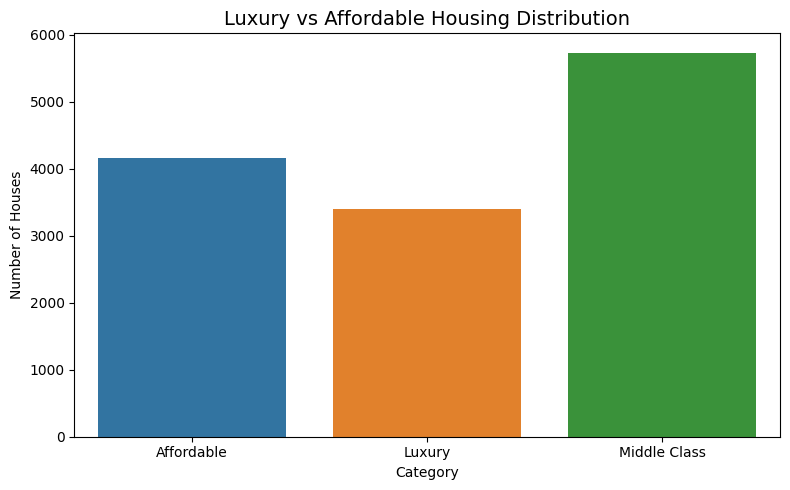

Category
Middle Class    5736
Affordable      4168
Luxury          3403
Name: count, dtype: int64


In [50]:
# Create category column first
def classify_luxury(score):
    if score >= 11:
        return 'Luxury'
    elif score <= 7:
        return 'Affordable'
    else:
        return 'Middle Class'

df['Category'] = df['Luxury1'].apply(classify_luxury)

# Countplot
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x='Category',
    hue='Category',
    
    legend=False
)
plt.title('Luxury vs Affordable Housing Distribution', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Number of Houses')
plt.tight_layout()
plt.show()

# Verify counts
print(df['Category'].value_counts())

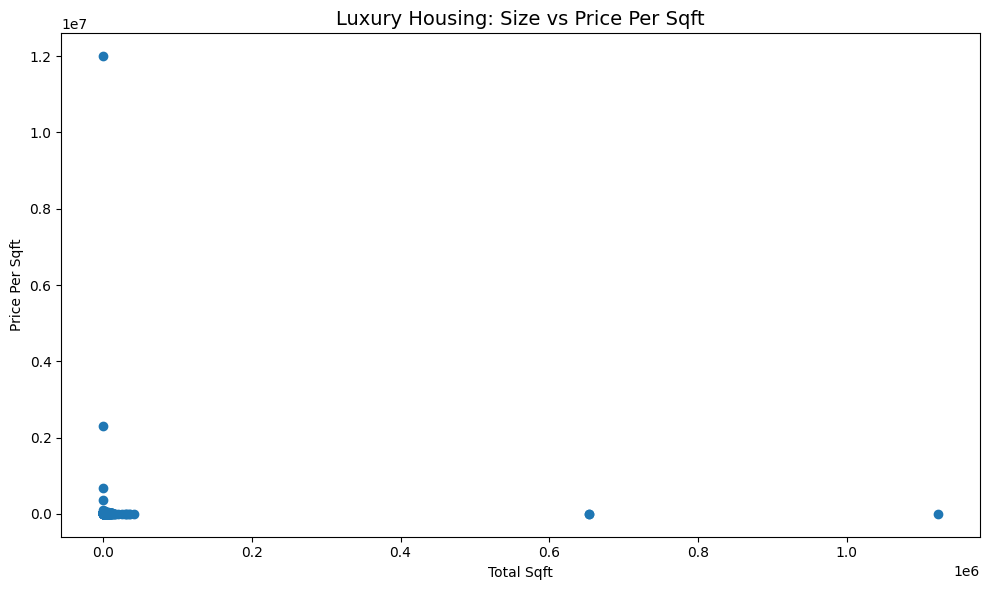

In [51]:
plt.figure(figsize=(10, 6))
plt.scatter(
    luxury['total_sqft'],
    luxury['price_per_sqft'],

    
)
plt.title('Luxury Housing: Size vs Price Per Sqft', fontsize=14)
plt.xlabel('Total Sqft')
plt.ylabel('Price Per Sqft')
plt.tight_layout()
plt.show()

In [52]:
high_luxury = df.loc[df['Luxury1'] >= 11, ['location', 'total_sqft', 'price_per_sqft', 'size_num', 'Luxury1']]
print(high_luxury)

                location  total_sqft  price_per_sqft  size_num  Luxury1
1       Chikka Tirupathi      2600.0     4615.384615         4     16.0
6       Old Airport Road      2732.0     7467.057101         4     13.0
7           Rajaji Nagar      3300.0    18181.818182         4     13.0
9                  other      1020.0    36274.509804         6     17.0
11            Whitefield      2785.0    10592.459605         4     16.0
...                  ...         ...             ...       ...      ...
13311   Ramamurthy Nagar      1500.0    16666.666667         7     21.0
13314  Green Glen Layout      1715.0     6530.612245         3     11.0
13315         Whitefield      3453.0     6689.834926         5     11.0
13316              other      3600.0    11111.111111         4     14.0
13318    Padmanabhanagar      4689.0    10407.336319         4     12.0

[3403 rows x 5 columns]


In [53]:
top_dot = luxury.loc[luxury['price_per_sqft'] == luxury['price_per_sqft'].max(), 
                     ['location', 'total_sqft', 'price_per_sqft']]
print(top_dot)

            location  total_sqft  price_per_sqft
4086  Sarjapur  Road         1.0      12000000.0


In [54]:
#Q: Developers ke liye kaunsa segment profitable hai? -->
df['price_per_sqft'].mean() # 7904.2891002203105
df['price_per_sqft'].max() # 12000000
df['price_per_sqft'].min() # 2.2574227119681667

2.2574227119681667

In [55]:
# df=df.drop(columns=['price_per_sqft_encode'])
# df=df.drop(columns=['Developer_profit'])

In [56]:
#Q: Developers ke liye kaunsa segment profitable hai? -->

# Step 1: Filter small sqft + high price
mean_sqft  = df['total_sqft'].mean()
mean_price = df['price_per_sqft'].mean()

# Step 2: Keep only profitable segment
profitable = df[
    (df['total_sqft'] < mean_sqft) &        # small units
    (df['price_per_sqft'] > mean_price)     # high price
]

# Step 3: Group by location
result = profitable.groupby('location')['price_per_sqft']\
                   .mean()\
                   .sort_values(ascending=False)\
                   .reset_index()\
                   
print(mean_sqft)
print(mean_price)
print(result)
print("Total rows after filter:", len(profitable))
print("Avg sqft:", profitable['total_sqft'].mean())
print('\n',result.columns)
print(result.shape)

1912.9831418080712
7904.2891002203105
                     location  price_per_sqft
0              Sarjapur  Road   454069.857143
1                  Whitefield    31322.801039
2             Judicial Layout    28098.664988
3                  HSR Layout    26653.891509
4    Electronic City Phase II    24583.333333
..                        ...             ...
189            Thigalarapalya     8169.845941
190                 Gottigere     8111.157254
191               Mahadevpura     8034.026465
192                  Nagavara     7954.545455
193         Green Glen Layout     7936.507937

[194 rows x 2 columns]
Total rows after filter: 1736
Avg sqft: 1199.2493006912443

 Index(['location', 'price_per_sqft'], dtype='object')
(194, 2)




# Here we have defined 3 steps in order of priority, where price_per_sqft and location_demand are equally weighted, but total_sqft is given less priority

row → calculator (temporary)
df['investment_score'] → your notebook (permanent) ✅
-
row['column']temporaryonly inside function
df['new_col']permanentstays in DataFrame ✅
-

row['column'] this also has a memory ? it remmbers right
yes but temporary::
-

# row['price_per_sqft'] → just READING the value
    # like opening a book to check a number
    # nothing created, nothing stored!

row['price_per_sqft'] → reading marks from marksheet
df['investment_score'] → writing final grade on marksheet
-

In [57]:
# Kaunsi location investment ke liye best hai?
location_freq = df['location'].value_counts()
df['location_encoded'] = df['location'].map(location_freq)

# Step 2: Investment score combining all 3
mean_price  = df['price_per_sqft'].mean()
mean_sqft   = df['total_sqft'].mean()
mean_demand = df['location_encoded'].mean()


# So row is actually a mini version of df for that one row:
def investment_score(row):
    score = 0
    
# Priority 1 (Weight: 3) → Low price = affordable entry point for investor
    if row['price_per_sqft'] <= mean_price:
        score += 3    # ✅ affordable
    else:
        score += 1    # ⚠️ expensive
    
# Priority 1 (Weight: 3) → High demand = proven market, less risk
    if row['location_encoded'] >= mean_demand:
        score += 3    # ✅ high demand
    else:
        score += 1    # ⚠️ low demand
    
# Priority 2 (Weight: 2) → Good size = value for money (less critical)
    if row['total_sqft'] >= mean_sqft:
        score += 2    # ✅ good size
    else:
        score += 1    # ⚠️ small size
    
    return score

df['investment_score'] = df.apply(investment_score, axis=1)

# Step 3: Top 10 investment locations
result = df.groupby('location')['investment_score']\
           .mean()\
           .sort_values(ascending=False)\
           .reset_index()\
           

print(result)

print(result.columns)
print(result.shape)

                 location  investment_score
0                   other          6.531023
1        Chikka Tirupathi          5.823529
2           Iblur Village          5.640000
3        Old Airport Road          5.333333
4          Talaghattapura          5.325000
..                    ...               ...
237           Basavangudi          3.612903
238           Benson Town          3.600000
239          Rajaji Nagar          3.532710
240   Sector 7 HSR Layout          3.384615
241  2nd Stage Nagarbhavi          3.333333

[242 rows x 2 columns]
Index(['location', 'investment_score'], dtype='object')
(242, 2)


# Key difference:

#  Key:                        if elif else                                        multiple if else
1. Blocks run                  only ONE block runs                                ALL blocks run ✅
2. Used for                    one decision                                       multiple independent decisions
3. Score                       single result                                      accumulates (+3, +3, +2) ✅

# Key Knowledge:
1. axis=1 → row by row (what we used):
Step 1         row 0                  price=5000, demand=518, sqft=200 (multiple columns)

2. axis=0 → column by column:
Step 1         price_per_sqft         column5000, 15000, 4500 (only one column)

                * Here- Each column has ONE type of data → cannot access other columns! ❌

   



In [58]:
def grade(marks):
    if marks >= 90:
        return 'A'
    elif marks >= 80:
        return 'B'
    elif marks >= 70:
        return 'C'
    else:
        return 'D'
print(grade(189))

A


In [59]:
def grade(marks):
    if marks >= 90:
        return 'A'
    else:
        return 'B'
    if score >= 70:  # Skip from here
        return 'C'
    else:
        return 'D'
print(grade(189))

A


In [60]:
df['investment_score'].tolist

<bound method IndexOpsMixin.tolist of 0        5
1        6
2        5
3        5
4        5
        ..
13315    6
13316    6
13317    5
13318    4
13319    5
Name: investment_score, Length: 13307, dtype: int64>

In [61]:
print(result)
print(result.columns)

                 location  investment_score
0                   other          6.531023
1        Chikka Tirupathi          5.823529
2           Iblur Village          5.640000
3        Old Airport Road          5.333333
4          Talaghattapura          5.325000
..                    ...               ...
237           Basavangudi          3.612903
238           Benson Town          3.600000
239          Rajaji Nagar          3.532710
240   Sector 7 HSR Layout          3.384615
241  2nd Stage Nagarbhavi          3.333333

[242 rows x 2 columns]
Index(['location', 'investment_score'], dtype='object')


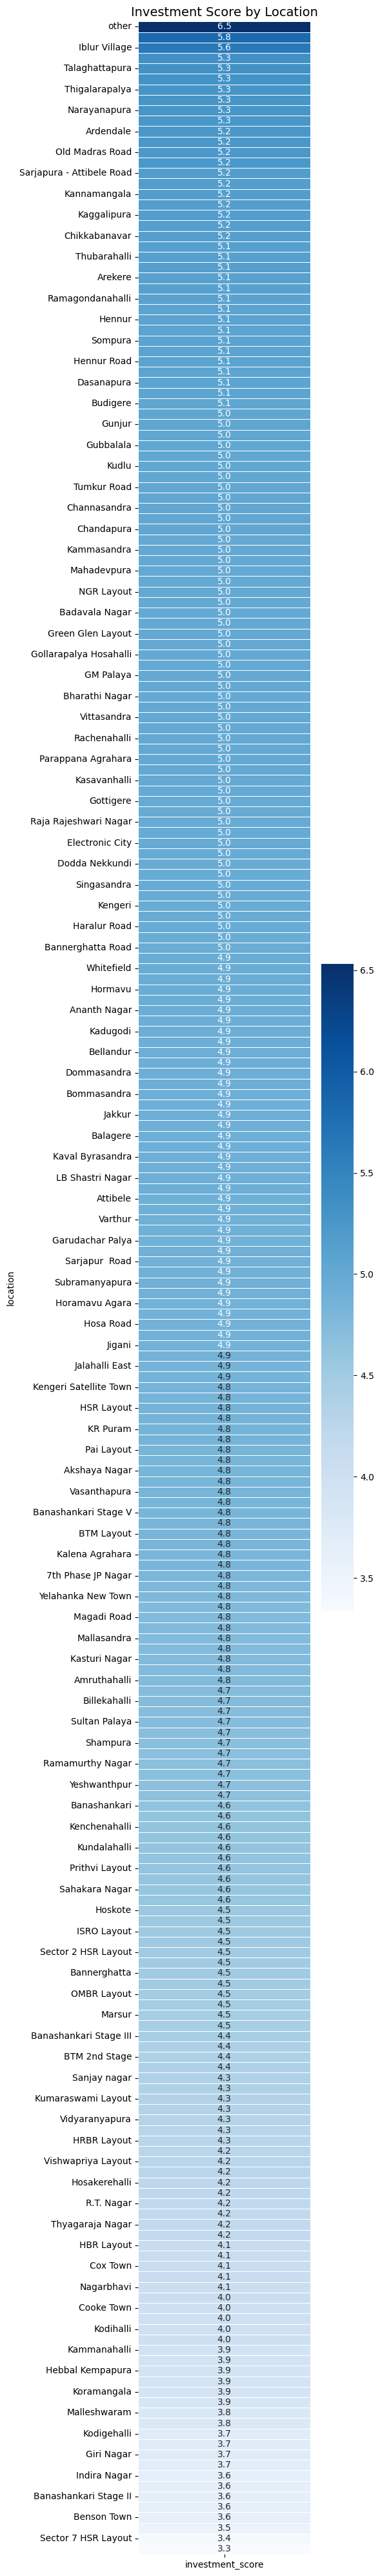

In [62]:
plt.figure(figsize=(6, 40))
sns.heatmap(
    result.set_index('location'),
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.5
)
plt.title('Investment Score by Location', fontsize=14)
plt.tight_layout()
plt.show()

(array([ 8., 12., 21., 24., 82., 85.,  7.,  2.,  0.,  1.]),
 array([3.33333333, 3.65310225, 3.97287117, 4.29264009, 4.61240901,
        4.93217793, 5.25194685, 5.57171577, 5.89148469, 6.21125361,
        6.53102253]),
 <BarContainer object of 10 artists>)

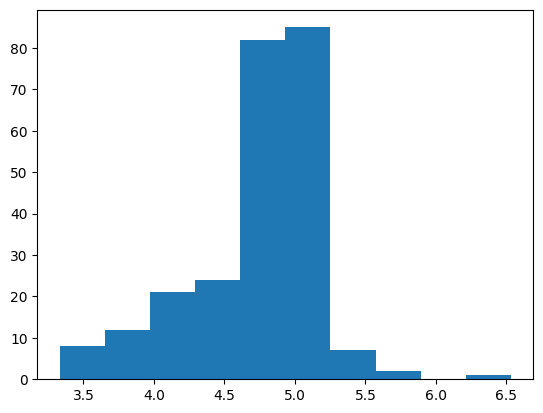

In [63]:
plt.hist(result['investment_score'], bins=10)

<Axes: ylabel='investment_score'>

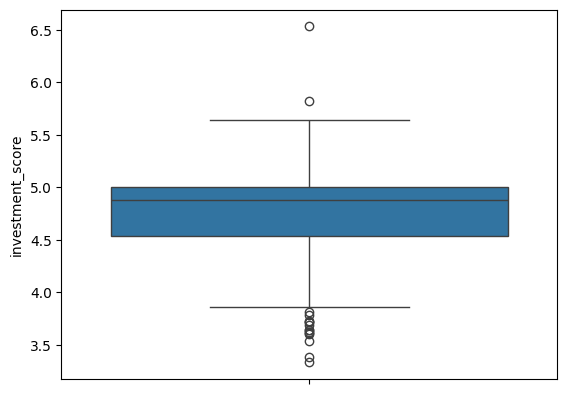

In [64]:
sns.boxplot(data=result, y='investment_score')

<Axes: >

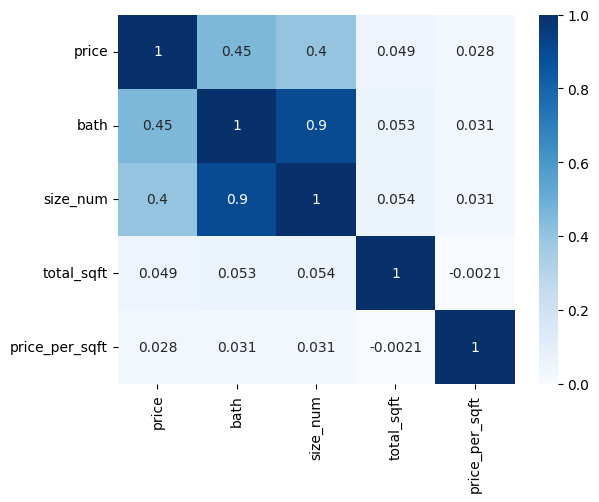

In [65]:
sns.heatmap(df[['price', 'bath', 'size_num', 
                'total_sqft', 'price_per_sqft']].corr(), 
            annot=True, cmap='Blues')

# Kahan price growth potential zyada hai?
1. Signal 1 → High demand + Moderate price
Many buyers + still affordable
= prices will rise soon!

2. Signal 2 → Infrastructure development
Near metro, IT parks, schools, hospitals
= people will move here → prices rise!
3. Signal 3 → Currently undervalued
Low price today + high demand
= hidden gem → buy now before price rises!

4. Signal 4 → New projects launching
Developers building new projects here
= they see future value → trust their research!

# From my data i can measure:
High location_demand  - people already interested 
Low price_per_sqft    - still affordable 
Good total_sqft       - value for money 

In [66]:
# Step 1: Growth potential score
def growth_potential_score(row):
    score = 0
    
    # Signal 1 (Weight: 4): Low price today = room to grow!
    if row['price_per_sqft'] <= mean_price:
        score += 4
    else:
        score += 1

    # Signal 2 (Weight: 4): High demand = people interested = prices will rise
    if row['location_encoded'] >= mean_demand:
        score += 4
    else:
        score += 1

    # Signal 3 (Weight: 2): Good size = value for money
    if row['total_sqft'] >= mean_sqft:
        score += 2
    else:
        score += 1

    return score

# Step 2: Apply
df['growth_score'] = df.apply(growth_potential_score, axis=1)

# Step 3: Top 10 locations with highest growth potential
result_growth = df.groupby('location')['growth_score']\
                  .mean()\
                  .sort_values(ascending=False)\
                  .reset_index()\
                  .head(10)

print(result_growth)

                    location  growth_score
0                      other      8.191681
1           Chikka Tirupathi      6.823529
2              Iblur Village      6.480000
3             Talaghattapura      6.300000
4               Narayanapura      6.272727
5                Nehru Nagar      6.272727
6                Dasarahalli      6.235294
7                Rajiv Nagar      6.230769
8           Old Airport Road      6.181818
9  Sarjapura - Attibele Road      6.176471


In [67]:
budget_50L= df[df['price']>=50] #if want to create new column do this gf['budget_50L'] 
df # as its only condition so thats why no column needed to be created
result= budget_50L.groupby('location')['price'].count().sort_values(ascending=False).reset_index().head(10)
print(result)

          location  price
0            other   2303
1       Whitefield    435
2   Sarjapur  Road    330
3   Kanakpura Road    199
4      Thanisandra    176
5           Hebbal    164
6     Marathahalli    160
7        Yelahanka    158
8  Electronic City    139
9      Hennur Road    137


In [68]:
df

,area_type,availability,location,total_sqft,bath,balcony,price,size_num,price_per_sqft,location_encoded,Area_type_encode,total_sqft_encode,Luxury1,Category,investment_score,growth_score
0,Super built-up Area,Soon to be Vacated,Electronic City Phase II,1056.0,2.0,1.0,39.07,2,3699.810606,132,2.0,0.0,7.0,Affordable,5,6
1,Plot Area,Ready To Move,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4,4615.384615,17,3.0,1.0,16.0,Luxury,6,7
2,Built-up Area,Ready To Move,Uttarahalli,1440.0,2.0,3.0,62.00,3,4305.555556,186,1.0,0.0,9.0,Middle Class,5,6
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3,6245.890861,23,2.0,0.0,9.0,Middle Class,5,6
4,Super built-up Area,Ready To Move,Kothanur,1200.0,2.0,1.0,51.00,2,4250.000000,66,2.0,0.0,7.0,Affordable,5,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,3453.0,4.0,0.0,231.00,5,6689.834926,541,1.0,1.0,11.0,Luxury,6,7
13316,Super built-up Area,Ready To Move,other,3600.0,5.0,2.0,400.00,4,11111.111111,2885,2.0,1.0,14.0,Luxury,6,7
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,1141.0,2.0,1.0,60.00,2,5258.545136,171,1.0,0.0,6.0,Affordable,5,6
13318,Super built-up Area,Soon to be Vacated,Padmanabhanagar,4689.0,4.0,1.0,488.00,4,10407.336319,28,2.0,1.0,12.0,Luxury,4,4


In [69]:
from sklearn.preprocessing import OrdinalEncoder

# Fix spaces first
df['area_type'] = df['area_type'].str.strip()
df['area_type'] = df['area_type'].str.replace('  ', ' ')

print(df['area_type'].unique())  # verify before encoding


['Super built-up Area' 'Plot Area' 'Built-up Area' 'Carpet Area']


In [70]:
from sklearn.preprocessing import OrdinalEncoder

# Order: smallest → largest measurement
grade_order = [['Carpet Area', 'Built-up Area', 'Super built-up Area', 'Plot Area']]
encoder1 = OrdinalEncoder(categories=grade_order)
df['area_type_encode'] = encoder1.fit_transform(df[['area_type']])

# Verify
print(df[['area_type', 'area_type_encode']].drop_duplicates())

               area_type  area_type_encode
0    Super built-up Area               2.0
1              Plot Area               3.0
2          Built-up Area               1.0
297          Carpet Area               0.0


In [71]:
print(df['availability'].unique())

['Soon to be Vacated' 'Ready To Move' 'Immediate Possession']


In [72]:
# Order: longest wait → immediate
# Immediate Possession = best → highest value
avail_order = [['Soon to be Vacated', 'Ready To Move', 'Immediate Possession']]
encoder2 = OrdinalEncoder(categories=avail_order)
df['availability_encode'] = encoder2.fit_transform(df[['availability']])

# Verify
print(df[['availability', 'availability_encode']].drop_duplicates())

             availability  availability_encode
0      Soon to be Vacated                  0.0
1           Ready To Move                  1.0
579  Immediate Possession                  2.0


In [73]:
from sklearn.preprocessing import MinMaxScaler

# Columns to normalize
cols_to_scale = [
    'price_per_sqft',
    'total_sqft',
    'size_num',
    'bath',
    'location_encoded',
    'area_type_encode',
    'availability_encode'
]

scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# Verify → all values should be between 0 and 1
print(df_scaled[cols_to_scale].describe().round(3))

       price_per_sqft  total_sqft   size_num       bath  location_encoded  \
count       13307.000   13307.000  13307.000  13307.000         13307.000   
mean            0.001       0.001      0.043      0.043             0.247   
std             0.009       0.013      0.031      0.034             0.398   
min             0.000       0.000      0.000      0.000             0.000   
25%             0.000       0.001      0.024      0.026             0.010   
50%             0.000       0.001      0.048      0.026             0.028   
75%             0.001       0.001      0.048      0.051             0.184   
max             1.000       1.000      1.000      1.000             1.000   

       area_type_encode  availability_encode  
count         13307.000            13307.000  
mean              0.653                0.399  
std               0.199                0.203  
min               0.000                0.000  
25%               0.667                0.500  
50%               0.667 

In [74]:
def buyer_score(row):
    score = 0
    score += (1 - row['price_per_sqft'])  * 5  # wants LOW price
    score += row['location_encoded']       * 4  # proven demand
    score += row['availability_encode']    * 4  # ready to move
    score += row['total_sqft']             * 3  # good size
    score += row['size_num']               * 3  # enough rooms
    score += row['bath']                   * 2  # amenities
    score += row['area_type_encode']       * 1  # less critical
    return score

def investor_score(row):
    score = 0
    score += row['location_encoded']       * 5  # high demand = appreciation
    score += (1 - row['price_per_sqft'])  * 4  # affordable entry point
    score += row['total_sqft']             * 3  # value for money
    score += row['size_num']               * 2  # moderate
    score += row['area_type_encode']       * 1  # less critical
    score += row['bath']                   * 1  # less critical
    score += row['availability_encode']    * 1  # less critical
    return score

def developer_score(row):
    score = 0
    score += row['area_type_encode']       * 5  # super built-up = max profit
    score += row['location_encoded']       * 4  # proven market
    score += row['total_sqft']             * 4  # bigger project = more revenue
    score += row['size_num']               * 3  # premium units
    score += row['bath']                   * 2  # luxury amenity
    score += (1 - row['price_per_sqft'])  * 2  # cheap land = more margin
    score += row['availability_encode']    * 1  # less critical
    return score

# Apply all 3
df_scaled['buyer_score']     = df_scaled.apply(buyer_score, axis=1)
df_scaled['investor_score']  = df_scaled.apply(investor_score, axis=1)
df_scaled['developer_score'] = df_scaled.apply(developer_score, axis=1)

print(df_scaled[['buyer_score', 'investor_score', 'developer_score']].describe().round(3))

       buyer_score  investor_score  developer_score
count    13307.000       13307.000        13307.000
mean         8.451           6.417            6.869
std          1.900           2.056            1.992
min          3.908           2.395            2.064
25%          7.667           5.243            5.836
50%          7.962           5.414            6.141
75%          8.579           6.070            7.942
max         14.874          13.073           15.123
